# 2/3 — Train the Ensemble and Validate It

**Run after notebook 1.** Trains 5 time2success models on the 49-dim
features and runs the diagnostics before any RL.

**Steps:** Sections 1–4 train the ensemble. Sections 5–7 are the
diagnostics that decide whether to proceed — read their output before
moving to notebook 3.

The key comparison: ensemble std in the mid-approach region, against the
previous 49-dim-less model. If explicit grasp features helped, disagreement
there should drop.

## 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
import os, json
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# SHARED FEATURE BUILDER — identical copy in all three notebooks.
# If you change it here, change it EVERYWHERE. A mismatch in column
# order fails silently: the model receives numbers in the wrong slots
# and returns plausible-looking garbage without raising.
# ============================================================
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6
FEATURE_DIM = 49

def build_features(obs):
    """39-dim raw obs -> 49-dim feature vector.

    Columns:
       0-38  raw obs (unchanged)
      39-41  hand->peg vector
      42-44  peg->goal vector
         45  |hand->peg|
         46  |peg->goal|
         47  gripper openness
         48  holding flag (0/1)
    """
    obs = np.asarray(obs, dtype=np.float32)
    hand = obs[HAND_POS_IDX]
    peg  = obs[PEG_POS_IDX]
    goal = obs[GOAL_POS_IDX]
    gripper = obs[GRIPPER_IDX]

    hand_to_peg_vec = peg - hand
    peg_to_goal_vec = goal - peg
    hand_to_peg = np.linalg.norm(hand_to_peg_vec)
    peg_to_goal = np.linalg.norm(peg_to_goal_vec)
    holding = float(gripper < GRIPPER_CLOSED_THRESHOLD and hand_to_peg < 0.06)

    return np.concatenate([
        obs,
        hand_to_peg_vec,
        peg_to_goal_vec,
        [hand_to_peg, peg_to_goal, gripper, holding],
    ]).astype(np.float32)

In [3]:
TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
RAW_OBS_DIM = _probe.observation_space.shape[0]
_probe.close()
print(f"DT={DT}, raw obs dim={RAW_OBS_DIM}, feature dim={FEATURE_DIM}")

DT=0.0125, raw obs dim=39, feature dim=49


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


In [4]:
class Time2SuccessModel(nn.Module):
    """dropout=0.2 must match whatever the saved checkpoints were trained with,
    or load_state_dict fails on layer-index mismatch."""
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


## 2. Load the dataset

In [6]:
DATASET_DIR = "./data/state_space_datasetV5"
data = np.load(os.path.join(DATASET_DIR, "dataset.npz"))
X, y_steps, episode_ids = data["X"], data["y_steps"], data["episode_ids"]

with open(os.path.join(DATASET_DIR, "dataset_summary.json")) as f:
    print(json.dumps(json.load(f), indent=2))

OBS_DIM = X.shape[1]
assert OBS_DIM == FEATURE_DIM, f"expected {FEATURE_DIM} columns, got {OBS_DIM}"
print(f"\n{X.shape[0]} rows, {OBS_DIM} features, {len(np.unique(episode_ids))} episodes")

{
  "total_rows": 60000,
  "total_episodes": 120,
  "feature_dim": 49,
  "dt_sec": 0.0125,
  "sources_used": [
    "sac_peg_insert_400000.zip",
    "sac_peg_insert_700000.zip",
    "sac_peg_insert_final.zip"
  ],
  "checkpoint_diversity": true,
  "avg_frames_per_episode": 500.0,
  "success_step_min": 41,
  "success_step_max": 255,
  "success_step_std": 36.21843357401802,
  "holding_fraction": 0.5842666625976562
}

60000 rows, 49 features, 120 episodes


## 3. Split and normalize

Split is by episode, not by row — adjacent frames within an episode are nearly identical, so a row-level split leaks and makes validation look better than it is.

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
train_idx, val_idx = next(gss.split(X, y_steps, groups=episode_ids))
X_train, y_train = X[train_idx], y_steps[train_idx]
X_val, y_val = X[val_idx], y_steps[val_idx]

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-8
y_mean, y_std = y_train.mean(), y_train.std()
X_train_n = (X_train - X_mean) / X_std
y_train_n = (y_train - y_mean) / y_std
X_val_n = (X_val - X_mean) / X_std
y_val_n = (y_val - y_mean) / y_std

print(f"train {len(X_train)} rows, val {len(X_val)} rows")
print(f"normalized targets: mean={y_train_n.mean():.4f}, std={y_train_n.std():.4f} "
      f"(should be ~0 and ~1)")

train 51000 rows, val 9000 rows
normalized targets: mean=-0.0000, std=1.0000 (should be ~0 and ~1)


## 4. Train the ensemble

Five members differing by seed. Similar val losses are expected — they differ in *where* they disagree, not in overall fit.

In [8]:
N_MODELS = 5
ENSEMBLE_DIR = "./checkpoints/time2success_ensemble_v5"
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

EPOCHS, PATIENCE = 300, 30

for model_idx in range(N_MODELS):
    torch.manual_seed(model_idx)
    np.random.seed(model_idx)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_n, dtype=torch.float32),
                                              torch.tensor(y_train_n, dtype=torch.float32)),
                               batch_size=256, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_n, dtype=torch.float32),
                                            torch.tensor(y_val_n, dtype=torch.float32)),
                             batch_size=256)

    model = Time2SuccessModel(obs_dim=OBS_DIM).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    best_path = os.path.join(ENSEMBLE_DIR, f"model_{model_idx}.pt")
    best_val = float("inf")          # reset per member
    stale = 0

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vl += loss_fn(model(xb), yb).item() * xb.size(0)
        vl /= len(X_val)

        if vl < best_val:
            best_val, stale = vl, 0
            torch.save(model.state_dict(), best_path)
        else:
            stale += 1
            if stale >= PATIENCE:
                break

    print(f"model {model_idx}: best val MSE(norm)={best_val:.4f}, stopped epoch {epoch}")

np.savez(os.path.join(ENSEMBLE_DIR, "normalization.npz"),
         X_mean=X_mean, X_std=X_std, y_mean=y_mean, y_std=y_std)
print(f"\nSaved to {ENSEMBLE_DIR}")

model 0: best val MSE(norm)=0.3796, stopped epoch 72
model 1: best val MSE(norm)=0.3396, stopped epoch 137
model 2: best val MSE(norm)=0.3491, stopped epoch 60
model 3: best val MSE(norm)=0.4153, stopped epoch 46
model 4: best val MSE(norm)=0.3752, stopped epoch 61

Saved to ./checkpoints/time2success_ensemble_v5


## 5. Load the ensemble for diagnostics

In [9]:
norm = np.load(os.path.join(ENSEMBLE_DIR, "normalization.npz"))
X_MEAN, X_STD = norm["X_mean"], norm["X_std"]
Y_MEAN, Y_STD = norm["y_mean"].item(), norm["y_std"].item()
assert X_MEAN.shape[0] == FEATURE_DIM, "normalization dim mismatch — wrong ensemble dir?"

ensemble = []
for i in range(N_MODELS):
    m = Time2SuccessModel(obs_dim=FEATURE_DIM).to(device)
    m.load_state_dict(torch.load(os.path.join(ENSEMBLE_DIR, f"model_{i}.pt")))
    m.eval()      # dropout off — disagreement must come from different fits,
                  # not from random dropout masks
    ensemble.append(m)

@torch.no_grad()
def predict_t2s_ensemble(obs):
    """Raw 39-dim obs -> (mean, std) predicted steps remaining."""
    feat = build_features(obs)
    x = torch.tensor((feat - X_MEAN) / X_STD, dtype=torch.float32).unsqueeze(0).to(device)
    preds = np.array([m(x).item() for m in ensemble]) * Y_STD + Y_MEAN
    return preds.mean(), preds.std()

def predict_t2s(obs):
    return predict_t2s_ensemble(obs)[0]

final_policy = SAC.load("./checkpoints/peg_insert_side/sac_peg_insert_final")
_m, _s = predict_t2s_ensemble(make_env(seed=0).reset()[0])
print(f"at a reset state: mean={_m:.1f}, std={_s:.1f} steps")

at a reset state: mean=54.0, std=5.8 steps


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 6. Ranking test (pre-success only)

Measures whether the model orders states correctly, which is what the reward
actually depends on. Restricted to pre-success frames — including the
post-success zeros creates a large tied block that drags the correlation down
for reasons unrelated to model quality.

Previous model scored 13/15 seeds above 0.83, with two failures at 0.02 and
−0.25. Compare against that.

In [10]:
def ranking_test(n_episodes=15, start_seed=500, max_steps=500):
    rhos, seeds_used = [], []
    for seed in range(start_seed, start_seed + n_episodes):
        e = make_env(seed=seed)
        obs, _ = e.reset()
        preds, ss = [], None
        for t in range(max_steps):
            preds.append(predict_t2s(obs))
            a, _ = final_policy.predict(obs, deterministic=True)
            obs, _, term, trunc, info = e.step(a)
            if info.get(SUCCESS_KEY, 0):
                ss = t
                break
            if term or trunc:
                break
        e.close()
        if ss is None or len(preds) < 10:
            continue
        rho, _ = spearmanr(preds, [ss - t for t in range(len(preds))])
        rhos.append(rho); seeds_used.append(seed)
    rhos = np.array(rhos)
    for s, r in zip(seeds_used, rhos):
        flag = "  <-- LOW" if r < 0.7 else ""
        print(f"  seed {s}: rho={r:+.3f}{flag}")
    print(f"\nmean={rhos.mean():.3f}, min={rhos.min():.3f}, "
          f"below 0.7: {(rhos < 0.7).sum()}/{len(rhos)}")
    return rhos, seeds_used

rhos, seeds_used = ranking_test()

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


  seed 500: rho=+0.999
  seed 501: rho=+0.996
  seed 502: rho=+0.967
  seed 503: rho=+0.989
  seed 504: rho=+0.980
  seed 505: rho=+0.872
  seed 506: rho=+1.000
  seed 507: rho=+1.000
  seed 508: rho=+0.999
  seed 509: rho=+0.231  <-- LOW
  seed 510: rho=+0.989
  seed 511: rho=-0.271  <-- LOW
  seed 512: rho=+0.799
  seed 513: rho=+1.000
  seed 514: rho=+0.572  <-- LOW

mean=0.808, min=-0.271, below 0.7: 3/15


## 7. Per-seed predictions with uncertainty

Picks the worst and best seeds from the ranking test automatically.

seed 511 (worst): mean std=6.54, max std=12.02
seed 509 (2nd worst): mean std=7.33, max std=12.40
seed 506 (2nd best): mean std=1.73, max std=2.66
seed 513 (best): mean std=2.30, max std=3.27


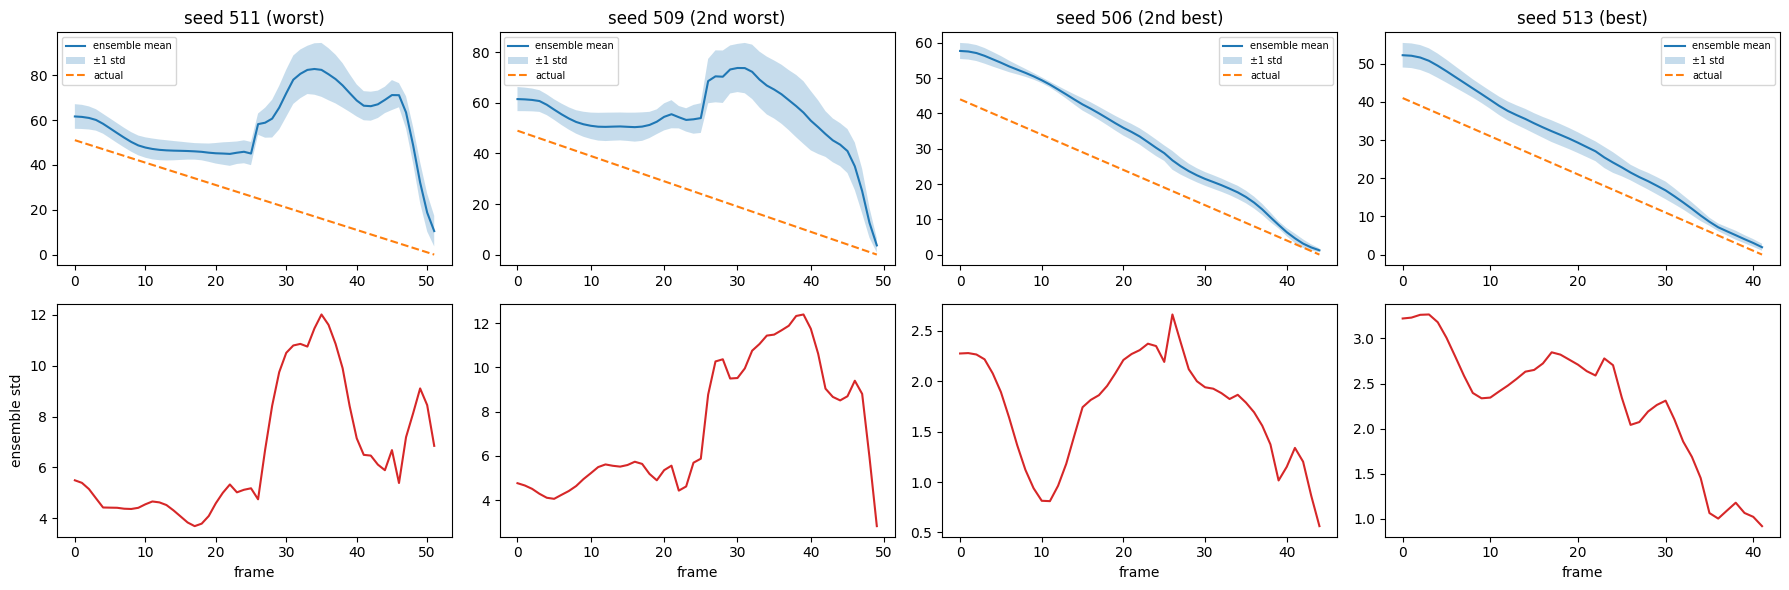

In [11]:
def trace(seed, max_steps=500):
    e = make_env(seed=seed)
    obs, _ = e.reset()
    preds, stds, ss = [], [], None
    for t in range(max_steps):
        m_, s_ = predict_t2s_ensemble(obs)
        preds.append(m_); stds.append(s_)
        a, _ = final_policy.predict(obs, deterministic=True)
        obs, _, term, trunc, info = e.step(a)
        if info.get(SUCCESS_KEY, 0):
            ss = t; break
        if term or trunc:
            break
    e.close()
    return np.array(preds), np.array(stds), ss

order = np.argsort(rhos)
show = [seeds_used[i] for i in list(order[:2]) + list(order[-2:])]
labels = ["worst", "2nd worst", "2nd best", "best"]

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for col, (seed, lab) in enumerate(zip(show, labels)):
    p, s, ss = trace(seed)
    n = len(p)
    axes[0, col].plot(p, label="ensemble mean")
    axes[0, col].fill_between(range(n), p - s, p + s, alpha=0.25, label="±1 std")
    axes[0, col].plot([max(0, ss - t) for t in range(n)], "--", label="actual")
    axes[0, col].set_title(f"seed {seed} ({lab})")
    axes[0, col].legend(fontsize=7)
    axes[1, col].plot(s, color="tab:red")
    axes[1, col].set_ylabel("ensemble std" if col == 0 else "")
    axes[1, col].set_xlabel("frame")
    print(f"seed {seed} ({lab}): mean std={s.mean():.2f}, max std={s.max():.2f}")
plt.tight_layout(); plt.show()

### Decide before notebook 3

- Ranking: fewer than the previous 2/15 low seeds → features helped.
- Std in the mid-approach region lower than the previous ~10–12 peak
  → the grasp features reduced disagreement where it mattered.
- If neither improved, the binding constraint is training-data coverage
  (no failure or off-trajectory states), not features — running the RL
  stage again would likely reproduce the same result.

In [12]:
d = np.load("./data/state_space_datasetV5/dataset.npz")
X, y, eps, hold = d["X"], d["y_steps"], d["episode_ids"], d["holding_flags"]

pre = (hold == 0) & (y > 0)
post = (hold == 1) & (y > 0)
print(f"pre-grasp rows:  {pre.sum()}")
print(f"post-grasp rows: {post.sum()}")
print(f"ratio: {post.sum()/pre.sum():.2f}")

pre-grasp rows:  4354
post-grasp rows: 4117
ratio: 0.95


In [13]:
from scipy.stats import spearmanr
preds = np.array([predict_t2s_ensemble(X[i][:39])[0] for i in range(0, len(X), 20)])
sub = slice(None, None, 20)
h, yy = hold[sub], y[sub]
m_pre, m_post = (h == 0) & (yy > 0), (h == 1) & (yy > 0)
print("pre-grasp  rho:", spearmanr(preds[m_pre], yy[m_pre])[0])
print("post-grasp rho:", spearmanr(preds[m_post], yy[m_post])[0])

pre-grasp  rho: 0.9296346022097474
post-grasp rho: 0.9336653007628146


In [16]:
import glob

# Earliest checkpoint = least competent policy, fails most of the time
early_ckpt = sorted(glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
                     key=lambda p: int("".join(c for c in os.path.basename(p) if c.isdigit()) or 0))[0]
early = SAC.load(early_ckpt)
print("using:", os.path.basename(early_ckpt))

def probe_random(seed, max_steps=300):
    e = make_env(seed=seed)
    obs, _ = e.reset()
    means, stds = [], []
    for t in range(max_steps):
        m_, s_ = predict_t2s_ensemble(obs)
        means.append(m_); stds.append(s_)
        obs, _, term, trunc, info = e.step(e.action_space.sample())
        if info.get(SUCCESS_KEY, 0):
            e.close(); return None
        if term or trunc:
            break
    e.close()
    return np.array(means), np.array(stds)

failing = []
for seed in range(300, 320):
    out = probe_random(seed)
    if out is not None:
        failing.append((seed, out[0], out[1]))
    if len(failing) >= 5:
        break
print(f"collected {len(failing)} random-action rollouts")
        
for seed, m, s in failing:
    print(f"  seed {seed}: pred start={m[0]:.1f}, end={m[-1]:.1f}, "
          f"min={m.min():.1f}, mean std={s.mean():.1f}")

using: sac_peg_insert_final.zip
collected 5 random-action rollouts
  seed 300: pred start=67.1, end=62.1, min=48.8, mean std=3.8
  seed 301: pred start=165.3, end=141.7, min=85.1, mean std=31.3
  seed 302: pred start=86.7, end=94.4, min=82.1, mean std=18.4
  seed 303: pred start=55.0, end=49.6, min=46.6, mean std=4.5
  seed 304: pred start=54.7, end=34.6, min=32.4, mean std=3.6


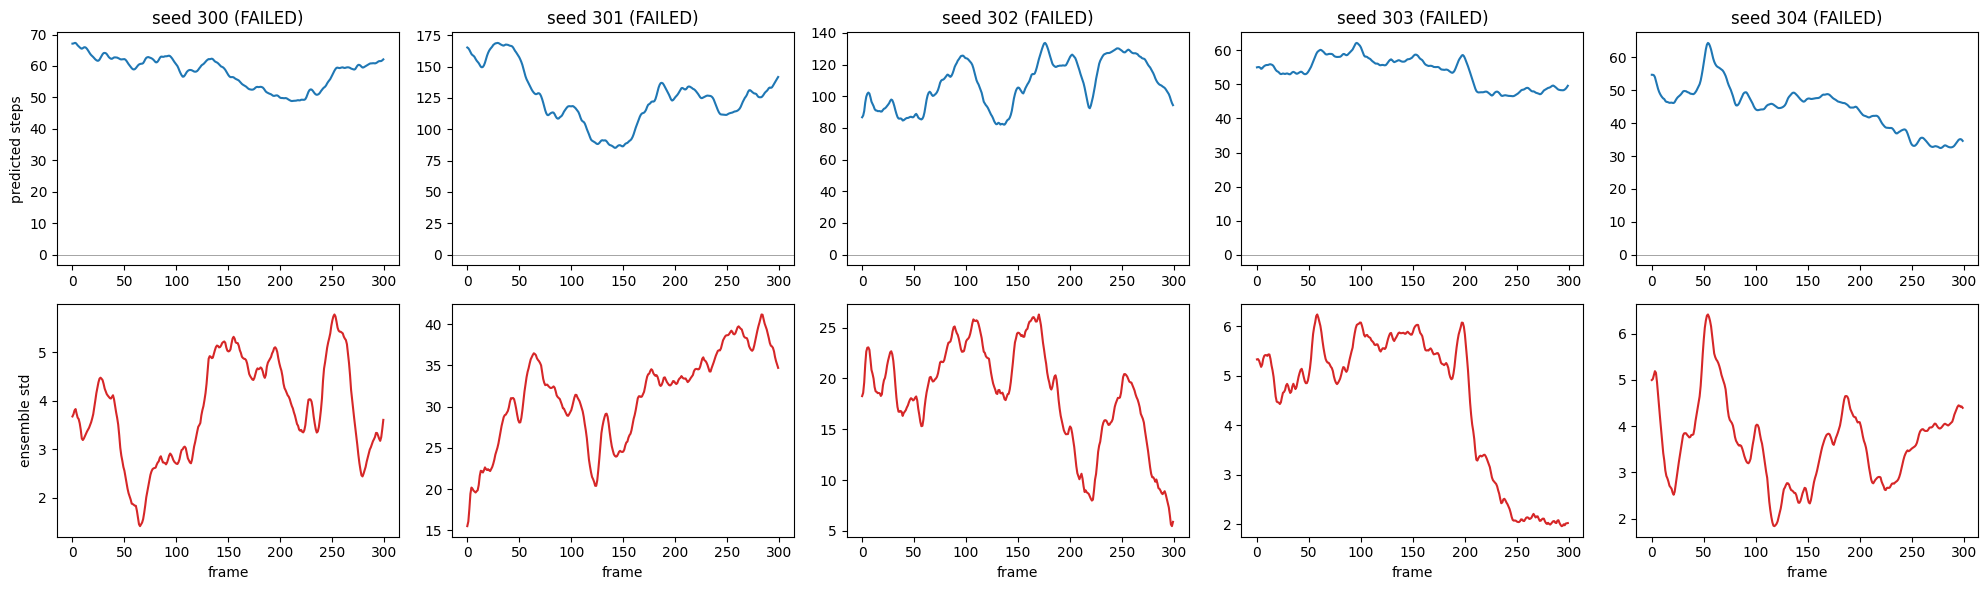

In [17]:
fig, axes = plt.subplots(2, len(failing), figsize=(4*len(failing), 6), squeeze=False)
for col, (seed, m, s) in enumerate(failing):
    axes[0, col].plot(m)
    axes[0, col].axhline(0, color="gray", lw=0.5)
    axes[0, col].set_title(f"seed {seed} (FAILED)")
    axes[0, col].set_ylabel("predicted steps" if col == 0 else "")
    axes[1, col].plot(s, color="tab:red")
    axes[1, col].set_ylabel("ensemble std" if col == 0 else "")
    axes[1, col].set_xlabel("frame")
plt.tight_layout(); plt.show()